# **🛒 Sales Profit Prediction: Baseline to Best Model**

**What this notebook does (step by step):**
1. Load and understand the sales data (20,000 orders)
2. Clean the data and create simple date features
3. Explore the data with a few easy charts (EDA)
4. Train several models, from a **baseline** to **advanced** ones
5. Improve the best idea with a smart trick (predict *profit margin*)
6. Compare all results and write a conclusion

**Goal:** predict the `profit` of an order (a **regression** problem).

## **1. Import Libraries**

In [1]:
import glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## **2. Load the Data**

In [2]:
# Works on Kaggle and locally: it searches for sales_data.csv automatically
path = (glob.glob("/kaggle/input/datasets/abirambharathisa/india-retail-sales-dataset-2023-2025/sales_data.csv", recursive=True)
        + glob.glob("sales_data.csv") + glob.glob("/mnt/user-data/uploads/sales_data.csv"))[0]
df = pd.read_csv(path, parse_dates=["order_date"])
print("Shape:", df.shape)
df.head()

Shape: (20000, 17)


,order_id,order_date,customer_id,gender,age,region,city,category,product,unit_price,quantity,discount,sales,profit,channel,payment_method,rating
0,ORD100001,2023-01-01,C00543,Male,43,North,Jaipur,Beauty,Sunscreen,557,4,0.00,2228.0,164.59,Store,UPI,5.0
1,ORD100002,2023-01-01,C01001,Female,40,South,Bengaluru,Home & Kitchen,Table Lamp,851,2,0.05,1616.9,160.72,Online,Cash on Delivery,4.0
2,ORD100003,2023-01-01,C00224,Female,34,East,Bhubaneswar,Books & Stationery,Exam Guide,544,1,0.10,489.6,75.61,Mobile App,UPI,4.0
3,ORD100004,2023-01-01,C01603,Male,27,East,Bhubaneswar,Home & Kitchen,Bedsheet Set,916,5,0.00,4580.0,439.43,Mobile App,UPI,4.0
4,ORD100005,2023-01-01,C00248,Male,21,West,Mumbai,Beauty,Sunscreen,574,1,0.05,545.3,116.65,Store,UPI,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        20000 non-null  object        
 1   order_date      20000 non-null  datetime64[ns]
 2   customer_id     20000 non-null  object        
 3   gender          20000 non-null  object        
 4   age             20000 non-null  int64         
 5   region          20000 non-null  object        
 6   city            20000 non-null  object        
 7   category        20000 non-null  object        
 8   product         20000 non-null  object        
 9   unit_price      20000 non-null  int64         
 10  quantity        20000 non-null  int64         
 11  discount        20000 non-null  float64       
 12  sales           20000 non-null  float64       
 13  profit          20000 non-null  float64       
 14  channel         20000 non-null  object        
 15  pa

**Note:** `rating` has some missing values. Rating is given *after* the purchase, so we will **not** use it to predict profit (using it would be unfair information).

## **3. Data Cleaning**

In [4]:
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("Duplicate orders:", df.duplicated("order_id").sum())

# Simple date features
df["month"] = df["order_date"].dt.month
df["day_of_week"] = df["order_date"].dt.dayofweek

# Profit margin = profit earned per rupee of sales (we use it later)
df["margin"] = df["profit"] / df["sales"]

# Check: sales should equal price x quantity x (1 - discount)
check = (df["sales"] - df["unit_price"] * df["quantity"] * (1 - df["discount"])).abs().max()
print("Max difference in sales formula:", round(check, 6))

Missing values:
 rating    200
dtype: int64
Duplicate orders: 0
Max difference in sales formula: 0.0


## **4. Exploratory Data Analysis (EDA)**

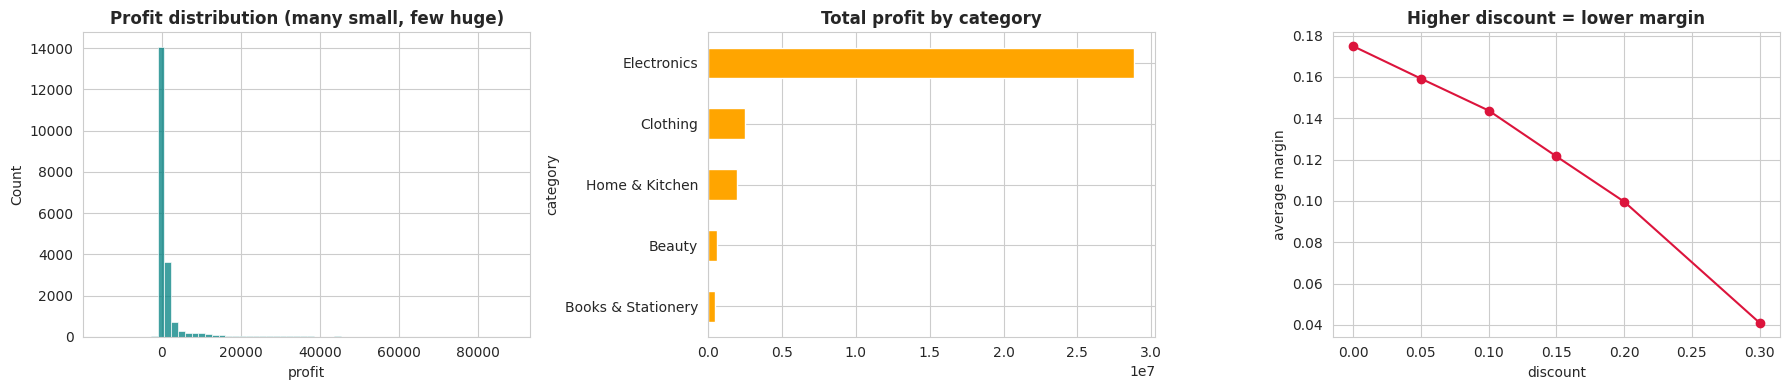

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["profit"], bins=60, ax=ax[0], color="teal")
ax[0].set_title("Profit distribution (many small, few huge)",fontweight='bold')

df.groupby("category")["profit"].sum().sort_values().plot.barh(ax=ax[1], color="orange")
ax[1].set_title("Total profit by category",fontweight='bold')

df.groupby("discount")["margin"].mean().plot(marker="o", ax=ax[2], color="crimson")
ax[2].set_title("Higher discount = lower margin",fontweight='bold')
ax[2].set_ylabel("average margin")
plt.tight_layout(); plt.show()

Loss-making orders: 1.93%


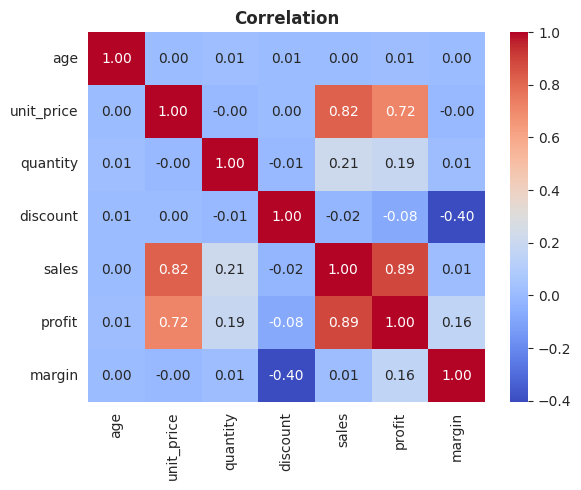

In [6]:
print("Loss-making orders: {:.2%}".format((df['profit'] < 0).mean()))
sns.heatmap(df[["age","unit_price","quantity","discount","sales","profit","margin"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm"); plt.title("Correlation",fontweight='bold'); plt.show()

**What we learned**
- Profit is very skewed: a few expensive orders (e.g., laptops) make most of the profit.
- `sales` is strongly related to `profit`.
- A bigger **discount lowers the margin** — an important hint for modelling.

## **5. Prepare Data for Modelling**
We convert text columns to numbers (one-hot encoding) and split into 80% train / 20% test.

In [7]:
features = ["age","gender","region","category","unit_price","quantity",
            "discount","sales","channel","payment_method","month","day_of_week"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (16000, 21)  Test: (4000, 21)


## **6. Train Models (Baseline → Advanced)**
We measure **R²** (closer to 1 is better), **MAE** (average error in ₹) and **RMSE**.

In [8]:
results = []
def evaluate(name, y_true, pred):
    results.append({"Model": name,
                    "R2": round(r2_score(y_true, pred), 4),
                    "MAE": round(mean_absolute_error(y_true, pred), 1),
                    "RMSE": round(np.sqrt(mean_squared_error(y_true, pred)), 1)})

models = {
    "Baseline (Mean)": DummyRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    evaluate(name, y_test, m.predict(X_test))

pd.DataFrame(results).sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
3,Random Forest,0.7918,719.4,2631.5
1,Linear Regression,0.7899,832.4,2643.2
4,Gradient Boosting,0.7732,743.1,2746.4
5,HistGradientBoosting,0.7674,739.2,2781.3
2,Decision Tree,0.7339,779.4,2974.6
0,Baseline (Mean),-0.0001,2337.7,5766.7


## **7. Smart Improvement: Predict Profit **Margin**, then Multiply by Sales**

Profit = `margin × sales`. We already know `sales` exactly, so the model only needs to guess the **margin** (a small number around 0.15 that mainly depends on discount). This removes the big-number problem and makes learning easier.

In [9]:
margin_train = df.loc[X_train.index, "margin"]
sales_test = df.loc[X_test.index, "sales"]

margin_models = {
    "Margin + Linear Regression": LinearRegression(),
    "Margin + Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=42),
    "Margin + HistGradientBoosting": HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=200, random_state=42),
}
for name, m in margin_models.items():
    m.fit(X_train, margin_train)
    evaluate(name, y_test, m.predict(X_test) * sales_test)

comparison = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
comparison

,Model,R2,MAE,RMSE
0,Margin + Linear Regression,0.8001,712.1,2578.1
1,Margin + HistGradientBoosting,0.7992,710.5,2584.0
2,Margin + Random Forest,0.7957,714.2,2606.3
3,Random Forest,0.7918,719.4,2631.5
4,Linear Regression,0.7899,832.4,2643.2
5,Gradient Boosting,0.7732,743.1,2746.4
6,HistGradientBoosting,0.7674,739.2,2781.3
7,Decision Tree,0.7339,779.4,2974.6
8,Baseline (Mean),-0.0001,2337.7,5766.7


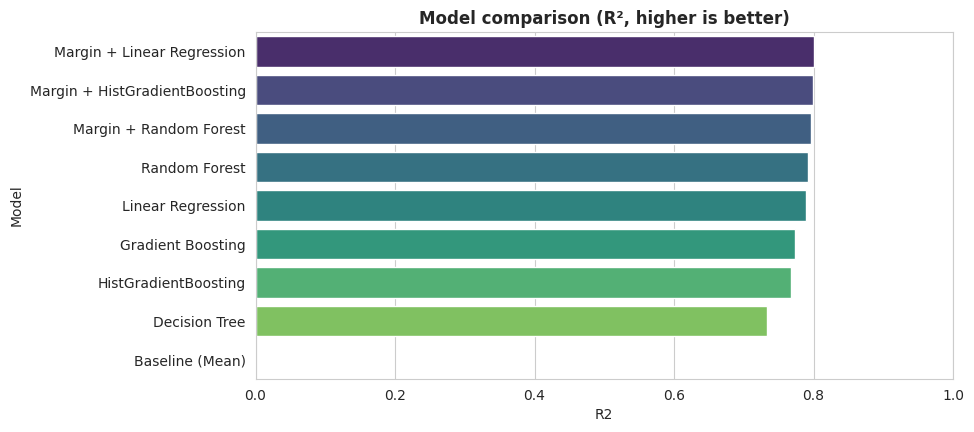

In [10]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison, y="Model", x="R2", palette="viridis")
plt.title("Model comparison (R², higher is better)",fontweight='bold'); plt.xlim(0, 1); plt.show()

## **8. Check the Best Model with Cross-Validation**
Cross-validation tests the model on 5 different splits, so the score is not just luck.

In [11]:
best = LinearRegression()
# Cross-validate the margin approach manually (5 folds)
from sklearn.model_selection import KFold
scores = []
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    best.fit(X.iloc[tr], df["margin"].iloc[tr])
    pred = best.predict(X.iloc[te]) * df["sales"].iloc[te]
    scores.append(r2_score(df["profit"].iloc[te], pred))
print("R² per fold:", np.round(scores, 3))
print("Average R²: {:.3f} (+/- {:.3f})".format(np.mean(scores), np.std(scores)))

R² per fold: [0.8   0.81  0.82  0.801 0.842]
Average R²: 0.815 (+/- 0.015)


## **9. Actual vs Predicted Profit**

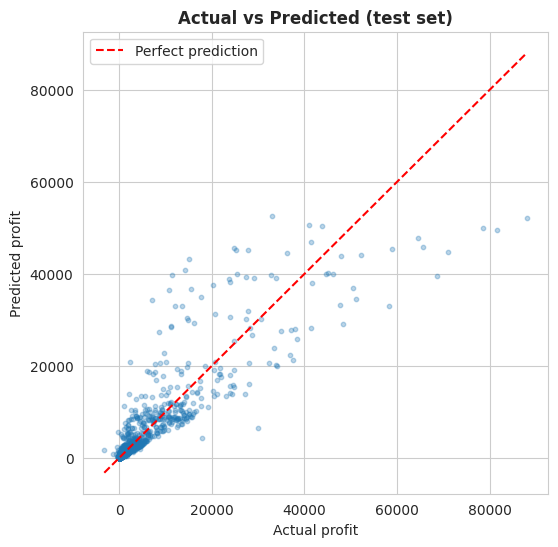

In [12]:
final = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=200, random_state=42)
final.fit(X_train, margin_train)
pred = final.predict(X_test) * sales_test

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3, s=10)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, "r--", label="Perfect prediction")
plt.xlabel("Actual profit"); plt.ylabel("Predicted profit"); plt.legend()
plt.title("Actual vs Predicted (test set)",fontweight='bold'); plt.show()

## **10. Conclusion**

- **Task:** predict order `profit` from 20,000 sales records.
- **Baseline** (always predict the average) gave R² ≈ 0. Linear Regression and Random Forest both reached about **0.79**; the boosting models scored a little lower (≈ 0.77) and a single Decision Tree ≈ 0.73.
- Predicting raw profit is hard because it is heavily skewed (a few huge orders).
- **Best approach:** predict the profit **margin**, then multiply by `sales`. This lifted R² to **0.80** on the test set (5-fold cross-validation average ≈ **0.81**) and gave the lowest MAE (≈ ₹710 on an average profit of ≈ ₹1,700).
- **Key business insight:** discount is the main driver of margin — every extra discount step cuts margin. Category, region, channel and customer age have almost no effect.
- **Why not higher?** The remaining ~20% looks like random noise in margin that none of the available columns can explain, so ~0.80 is close to the ceiling for this data.
- **Next steps:** add customer history, product cost or stock data, and try a classifier for loss-making orders (only ~2% of orders).